In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

print(Path.cwd())

d:\Anisha\Job\Aston_University\EuroSAT\notebooks


In [3]:
import importlib
import src.models

importlib.reload(src.models)

from src.models import resnet18_ms_model
from src.evaluation import *
from src.visualisation import *
from src.dataloader import *
from src.train import *
from src.config import *
from src.utils import *
import torch.nn as nn

create_dirs()


In [4]:
create_dirs()

from src.visualisation import *
from src.utils import *
from src.train import *
from src.dataloader import *

importlib.reload(src.dataloader)
importlib.reload(src.train)
importlib.reload(src.datasets)
importlib.reload(src.config)
importlib.reload(src.utils)
importlib.reload(src.visualisation)
importlib.reload(src.evaluation)

<module 'src.evaluation' from 'd:\\Anisha\\Job\\Aston_University\\EuroSAT\\src\\evaluation.py'>

### Load Data

In [5]:
train_ms_loader, val_ms_loader, test_ms_loader = load_ms_data()

print(len(train_ms_loader))
print(len(val_ms_loader))
print(len(test_ms_loader))

287
51
85


In [6]:
ms_images, ms_labels = next(iter(train_ms_loader))

print('MS Images : ', ms_images.shape)
print('MS Labels : ', ms_labels.shape)
print('MS Image dtype : ', ms_images.dtype)
print('MS label dtype : ', ms_labels.dtype)

MS Images :  torch.Size([64, 13, 64, 64])
MS Labels :  torch.Size([64])
MS Image dtype :  torch.float32
MS label dtype :  torch.int64


### Load Model

In [6]:
model = resnet18_ms_model()

model = model.to(get_device())

print(model.conv1)
print(model.fc)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=10, bias=True)


### Loss Function & Optimizer

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-4
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=5,  min_lr=1e-6
)


Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### Training Loop

In [8]:
history = training_loop(train_ms_loader, val_ms_loader, model, criterion, optimizer, 'ms_resnet18_v1.pth', scheduler)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/20] Train Loss : 0.3531 Train ACC : 0.8888 Val Loss : 0.1447 Val ACC : 0.9488 LR : 0.000100
Epoch [2/20] Train Loss : 0.1358 Train ACC : 0.9539 Val Loss : 0.0957 Val ACC : 0.9667 LR : 0.000100
Epoch [3/20] Train Loss : 0.1000 Train ACC : 0.9661 Val Loss : 0.1046 Val ACC : 0.9651 LR : 0.000100
Epoch [4/20] Train Loss : 0.0881 Train ACC : 0.9704 Val Loss : 0.0932 Val ACC : 0.9688 LR : 0.000100
Epoch [5/20] Train Loss : 0.0706 Train ACC : 0.9764 Val Loss : 0.0767 Val ACC : 0.9710 LR : 0.000100
Epoch [6/20] Train Loss : 0.0625 Train ACC : 0.9786 Val Loss : 0.0768 Val ACC : 0.9753 LR : 0.000100
Epoch [7/20] Train Loss : 0.0528 Train ACC : 0.9816 Val Loss : 0.0847 Val ACC : 0.9735 LR : 0.000100
Epoch [8/20] Train Loss : 0.0450 Train ACC : 0.9849 Val Loss : 0.0688 Val ACC : 0.9781 LR : 0.000100
Epoch [9/20] Train Loss : 0.0423 Train ACC : 0.9854 Val Loss : 0.0633 Val ACC : 0.9756 LR : 0.000100
Epoch [10/20] Train Loss : 0.0363 Train

### Evaluations

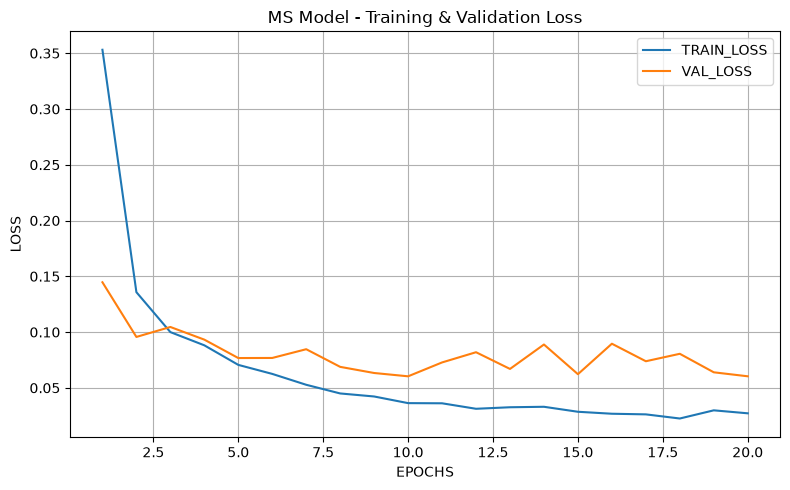

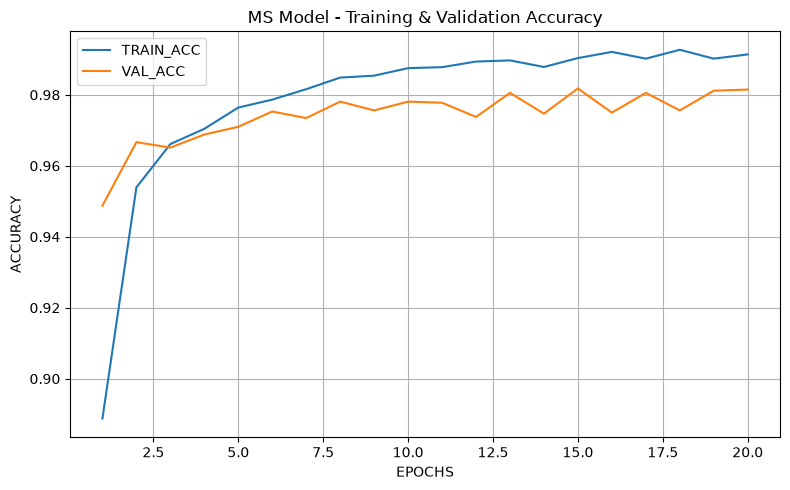

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0   0.98037          0.98008      0.980167  0.980019
                      precision    recall  f1-score     support
AnnualCrop             0.982759  0.950000  0.966102   600.00000
Forest                 0.993333  0.993333  0.993333   600.00000
HerbaceousVegetation   0.973109  0.965000  0.969038   600.00000
Highway                0.977867  0.972000  0.974925   500.00000
Industrial             0.986056  0.990000  0.988024   500.00000
Pasture                0.982278  0.970000  0.976101   400.00000
PermanentCrop          0.927894  0.978000  0.952288   500.00000
Residential            0.983526  0.995000  0.989229   600.00000
River                  0.993976  0.990000  0.991984   500.00000
SeaLake                1.000000  0.998333  0.999166   600.00000
accuracy               0.980370  0.980370  0.980370     0.98037
macro avg              0.980080  0.980167  0.980019  5400.00000
weighted a

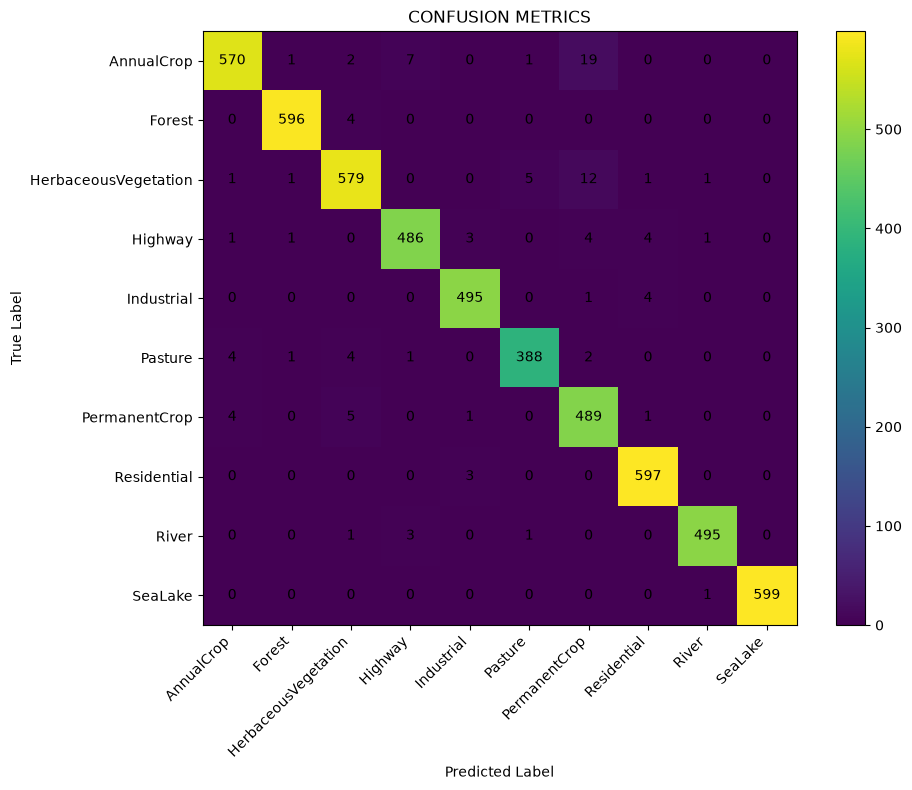

In [9]:
plot_all_evaluation(history, model, test_ms_loader, 'ms')

# MS Model Version 2

- Implementing Early Stopping & Weight Decay 

- Adding weight decay to the optimiser and early stopping is added here.

In [29]:
model = resnet18_ms_model()

model = model.to(get_device())

print(model.conv1)
print(model.fc)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=10, bias=True)


### Loss Fn & Optimiser

In [30]:
from src.early_stopping import *
import src.train
importlib.reload(src.config)
importlib.reload(src.train)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = LEARNING_RATE,
    weight_decay= WEIGHT_DECAY
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=5,  min_lr=1e-6
)

early_stop = EarlyStopping(patience=5, min_delta=0.0, checkpoint_path='ms_resnet18_with_earlystop_v2.pth')


Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


### Training Loop

In [31]:
history = training_loop(train_loader=train_ms_loader, val_loader=val_ms_loader, model=model, criterion=criterion, optimizer=optimizer, path_file='ms_resnet18_v2.pth', scheduler=scheduler, early_stop=early_stop)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/20] Train Loss : 0.3601 Train ACC : 0.8880 Val Loss : 0.1375 Val ACC : 0.9568 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [2/20] Train Loss : 0.1419 Train ACC : 0.9539 Val Loss : 0.1343 Val ACC : 0.9559 LR : 0.000100
Epoch [3/20] Train Loss : 0.0988 Train ACC : 0.9668 Val Loss : 0.0969 Val ACC : 0.9694 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [4/20] Train Loss : 0.0800 Train ACC : 0.9740 Val Loss : 0.0977 Val ACC : 0.9710 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [5/20] Train Loss : 0.0713 Train ACC : 0.9763 Val Loss : 0.0763 Val ACC : 0.9744 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [6/20] Train Loss : 0.0607 Train ACC : 0.9796 Val Loss : 0.0833 Val ACC : 0.9716 LR : 0.000100
Epoch [7/20] Train Loss : 0.0456 Train ACC : 0.9846 Val Loss : 0.0762 Val ACC : 0.9744 LR : 0.000100
Epoch [8/20] Train Loss : 0.0495 Train ACC : 0.9830 Val L

### Evaluations

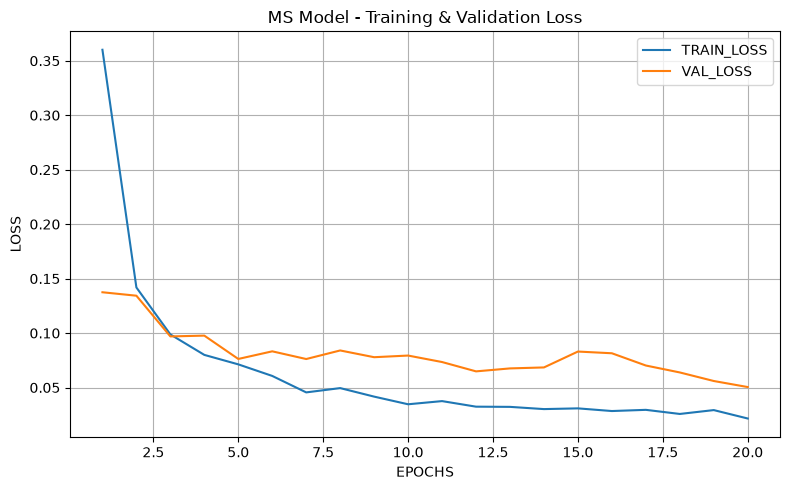

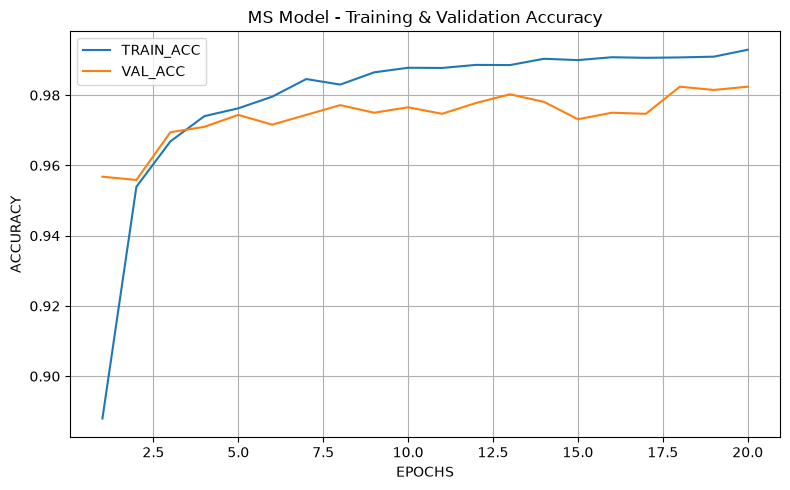

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
   accuracy  macro_precision  macro_recall  macro_f1
0  0.977593         0.977835      0.977117  0.977344
                      precision    recall  f1-score      support
AnnualCrop             0.975610  0.933333  0.954003   600.000000
Forest                 0.985197  0.998333  0.991722   600.000000
HerbaceousVegetation   0.942675  0.986667  0.964169   600.000000
Highway                0.979757  0.968000  0.973843   500.000000
Industrial             0.972603  0.994000  0.983185   500.000000
Pasture                0.982323  0.972500  0.977387   400.000000
PermanentCrop          0.963190  0.942000  0.952477   500.000000
Residential            0.988353  0.990000  0.989176   600.000000
River                  0.991968  0.988000  0.989980   500.000000
SeaLake                0.996672  0.998333  0.997502   600.000000
accuracy               0.977593  0.977593  0.977593     0.977593
macro avg              0.977835  0.977117  0.977344  5400.0000

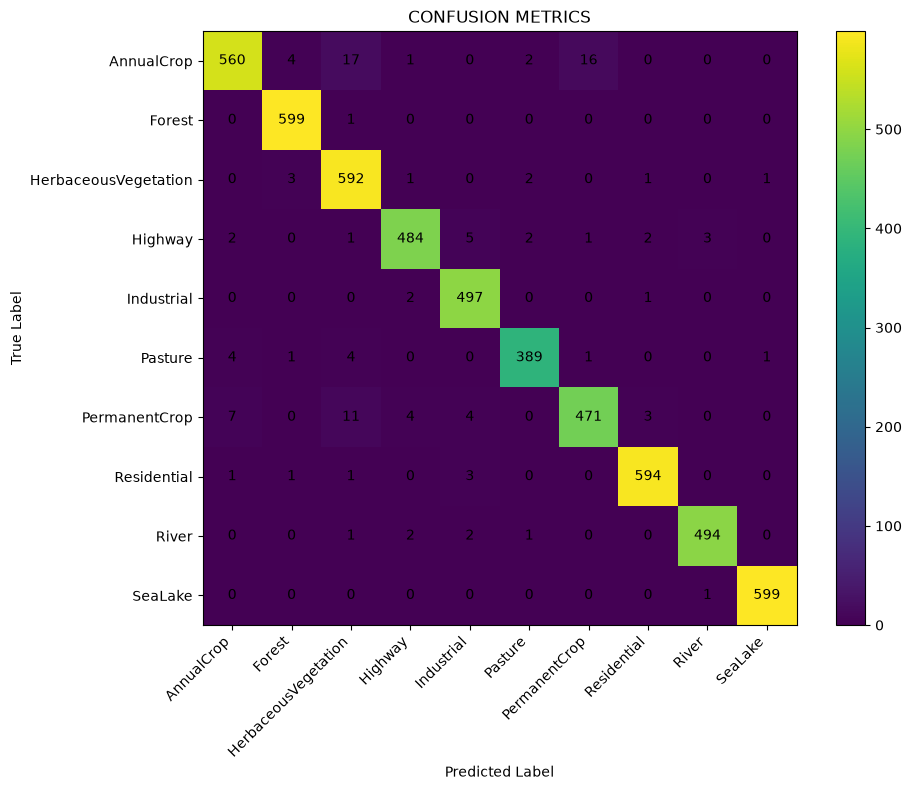

In [32]:
plot_all_evaluation(history, model, test_ms_loader, 'ms')

# V3

In [7]:
model = resnet18_ms_model()

model = model.to(get_device())

print(model.conv1)
print(model.fc)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Conv2d(13, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
Linear(in_features=512, out_features=10, bias=True)


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 1e-4
)

print('Loss Function : ', criterion)
print('Optimizer : ', optimizer)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=5,  min_lr=1e-6
)


Loss Function :  CrossEntropyLoss()
Optimizer :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [ ]:
history = training_loop(train_ms_loader, val_ms_loader, model, criterion, optimizer, 'ms_resnet18_v1.pth', scheduler)

GPU :  NVIDIA GeForce RTX 2060
CUDA version :  12.6
Epoch [1/30] Train Loss : 0.3583 Train ACC : 0.8855 Val Loss : 0.1544 Val ACC : 0.9519 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [2/30] Train Loss : 0.1393 Train ACC : 0.9556 Val Loss : 0.1321 Val ACC : 0.9556 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [3/30] Train Loss : 0.1017 Train ACC : 0.9665 Val Loss : 0.0912 Val ACC : 0.9691 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [4/30] Train Loss : 0.0773 Train ACC : 0.9729 Val Loss : 0.0804 Val ACC : 0.9725 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [5/30] Train Loss : 0.0665 Train ACC : 0.9778 Val Loss : 0.0753 Val ACC : 0.9731 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [6/30] Train Loss : 0.0665 Train ACC : 0.9778 Val Loss : 0.0631 Val ACC : 0.9812 LR : 0.000100
New Best Model Saved. Val Acc : {val_acc:.4f}
Epoch [7/30] Train Loss : 0.0542 Train ACC : 0.9822 Val Loss : 0.0

In [ ]:
plot_all_evaluation(history, model, test_ms_loader, 'ms')